# **Installation**

In [1]:
!pip install -q lightgbm catboost imbalanced-learn xgboost scikit-learn pandas numpy
!pip install ipython-autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.3 MB/s eta 0:00:00


# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import uniform

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (make_scorer, accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix, balanced_accuracy_score)
from imblearn.metrics import geometric_mean_score
from sklearn.model_selection import KFold
from imblearn.over_sampling import ADASYN
import time
from scipy.stats import uniform

# **Load Dataset**

In [3]:
df = pd.read_csv('/content/bank-additional-full.csv', sep=';')

# **Data Preprocessing**

In [4]:
# Drop Leakage Feature
df.drop('duration', axis=1, inplace=True)

# Handle "unknown" Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

# Encode Target & One-Hot Encoding
df['y'] = df['y'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, drop_first=True)

# Split Features & Target
X = df.drop('y', axis=1)
y = df['y']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **Scaling**


In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


# **Sampling Technique**

In [6]:
adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_s, y_train)

# **INSTALL LIBRARIES**

In [7]:
!pip install shap lime dalex scikit-learn matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 126.6 MB/s eta 0:00:00


# **XGboost**

In [8]:
from xgboost import XGBClassifier
#  Model base initialize
model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42, tree_method='hist')

# Parameter distribution setup
params = {
"n_estimators": [50, 100],
"learning_rate": [0.1, 0.2],
"max_depth": [3, 5, 6],
"subsample": [0.8],
"colsample_bytree":[0.8]
}

#  Randomized Search execution
rs = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=10,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Training
rs.fit(X_train_ad, y_train_ad)

# Best model extract
final_xg_model = rs.best_estimator_

print(f"Best Parameters: {rs.best_params_}")
print(f"Best CV Accuracy: {round(rs.best_score_, 4)}")

Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV Accuracy: 0.8822



--- SHAP EXPLANATION FOR XGBOOST ---


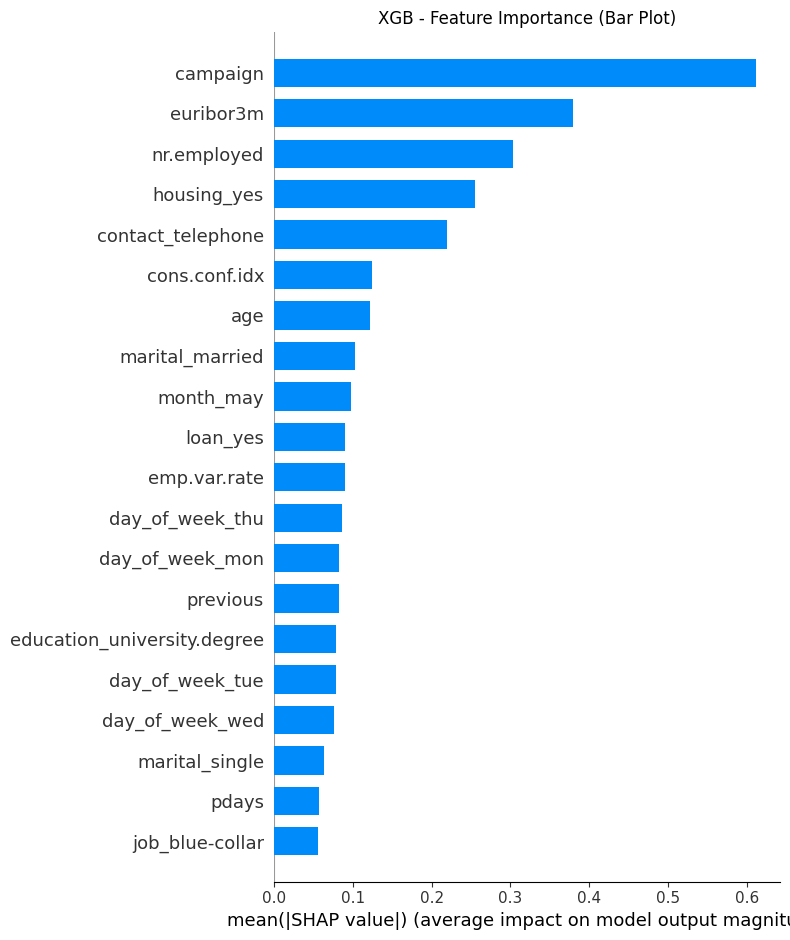

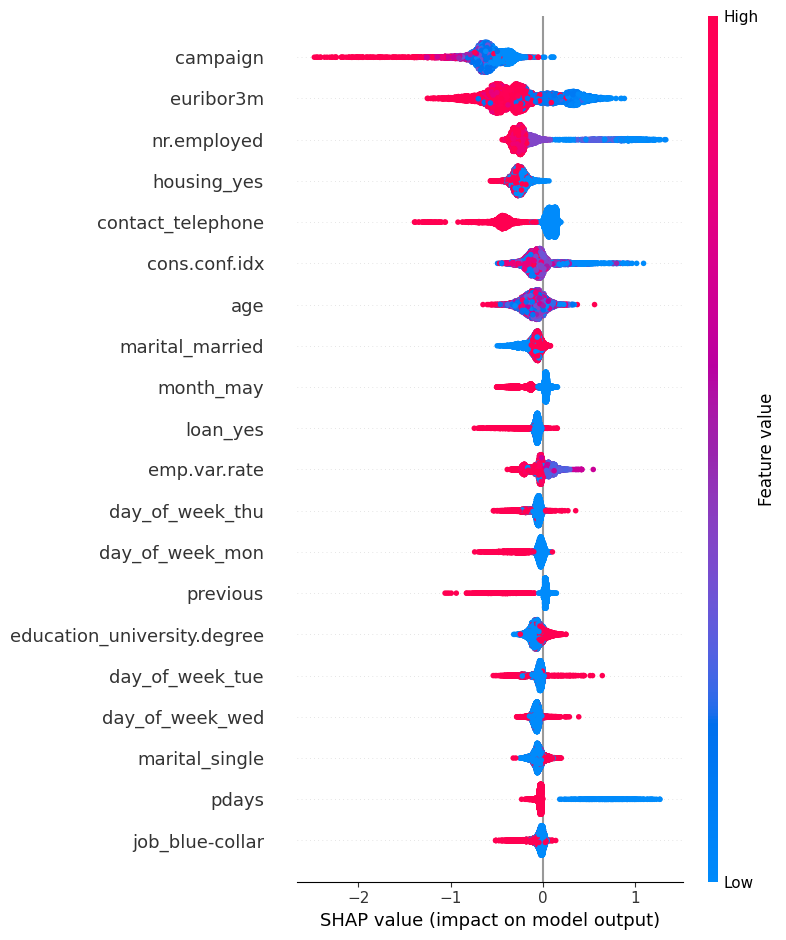

<Figure size 640x480 with 0 Axes>

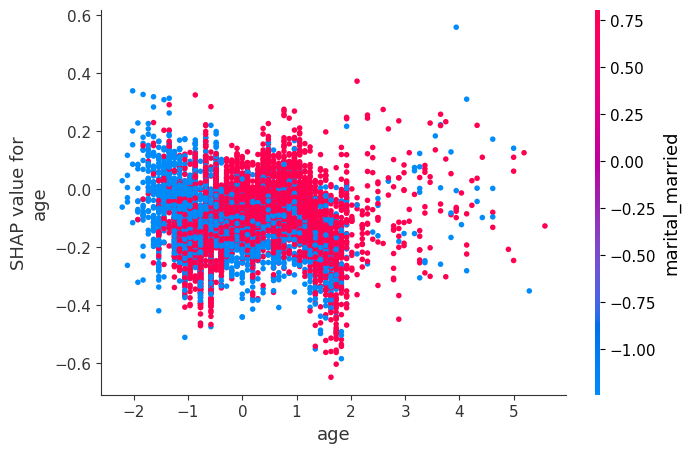

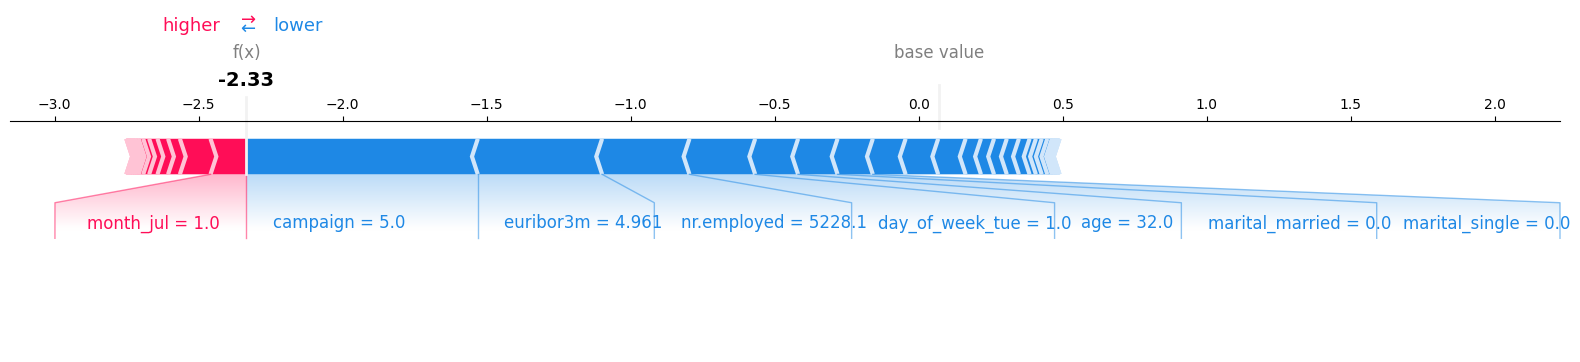

In [ ]:
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

print("\n--- SHAP EXPLANATION FOR XGBOOST ---")
explainer_xgb = shap.TreeExplainer(final_xg_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_s)

# 1. Global Bar Plot
plt.figure()
plt.title("XGB - Feature Importance (Bar Plot)")
shap.summary_plot(shap_values_xgb, X_test_s, feature_names=X.columns, plot_type="bar")

# 2. Summary Plot
plt.figure()
shap.summary_plot(shap_values_xgb, X_test_s, feature_names=X.columns)

# 3. Dependence Plot
plt.figure()
shap.dependence_plot(X.columns[0], shap_values_xgb, X_test_s, feature_names=X.columns)

# 4. Force Plot
shap.initjs()
shap.force_plot(explainer_xgb.expected_value, shap_values_xgb[0,:], X_test.iloc[0,:], feature_names=X.columns, matplotlib=True)

In [21]:
#  LIME EXPLAINABILITY
from lime.lime_tabular import LimeTabularExplainer

print("\n--- LIME EXPLANATION ---")

lime_explainer = LimeTabularExplainer(
    training_data=X_train_s,
    feature_names=X.columns,
    class_names=['Yes', 'No'],
    mode='classification'
)

lime_exp = lime_explainer.explain_instance(
    X_test_s[0],
    final_xg_model.predict_proba
)

lime_exp.show_in_notebook(show_table=True)




--- LIME EXPLANATION ---


# **LightGBM**

In [11]:
from lightgbm import LGBMClassifier
#  Model base initialize
model = LGBMClassifier(random_state=42,verbosity=-1)

# Parameter distribution setup
params = {
"n_estimators": [100, 150],
"learning_rate": [0.05, 0.1],
"num_leaves": [31, 40],
"boosting_type": ['gbdt']
}

#  Randomized Search execution
rs = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=10,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Training
rs.fit(X_train_ad, y_train_ad)

# Best model extract
final_lgbm_model = rs.best_estimator_

print(f"Best Parameters: {rs.best_params_}")
print(f"Best CV Accuracy: {round(rs.best_score_, 4)}")



Best Parameters: {'num_leaves': 40, 'n_estimators': 150, 'learning_rate': 0.1, 'boosting_type': 'gbdt'}
Best CV Accuracy: 0.8837



--- SHAP EXPLANATION FOR LIGHTGBM ---


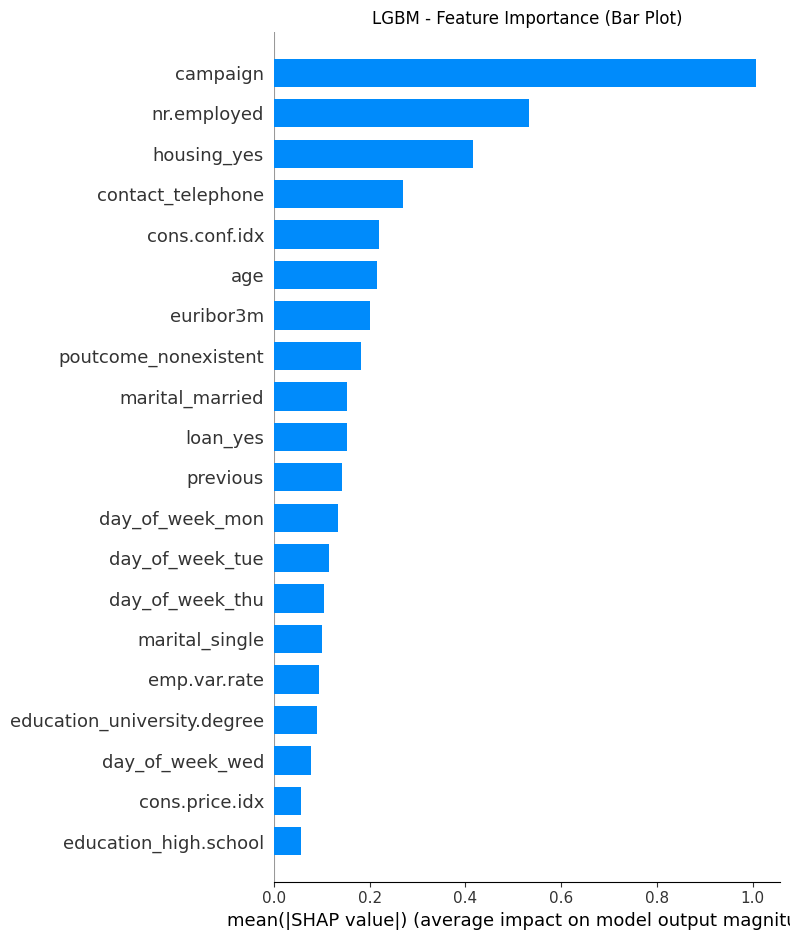

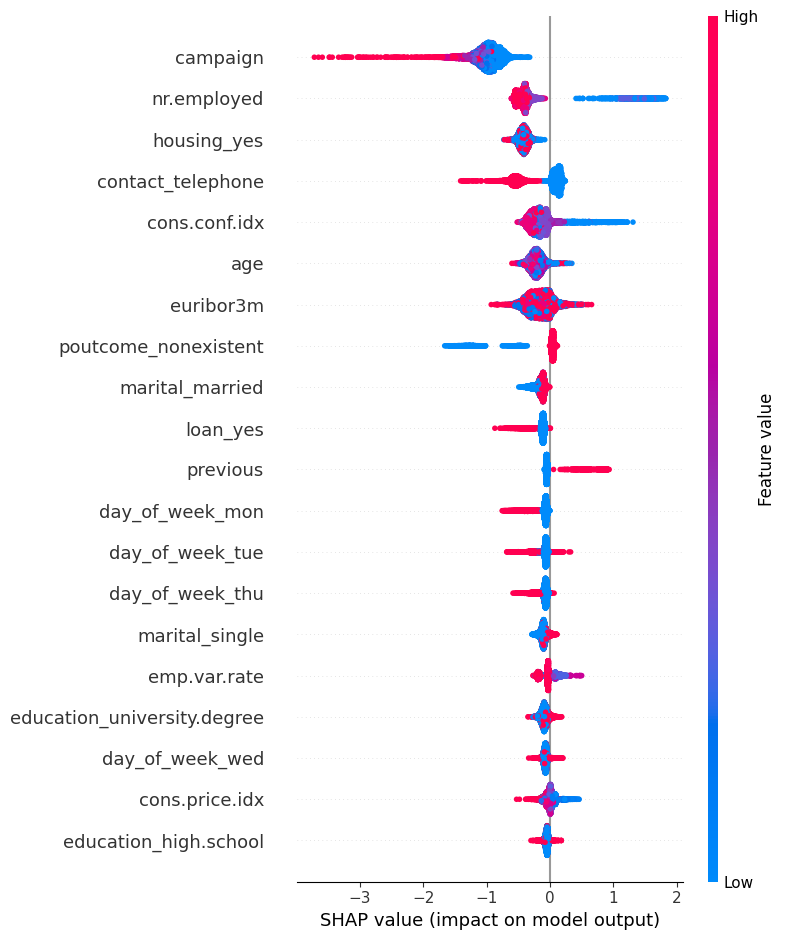

<Figure size 640x480 with 0 Axes>

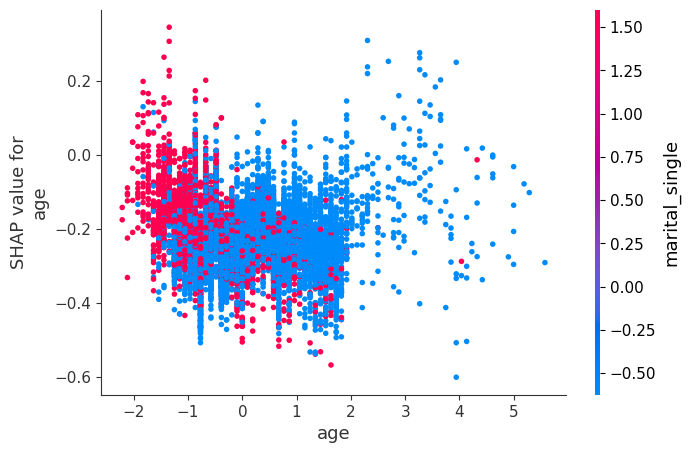

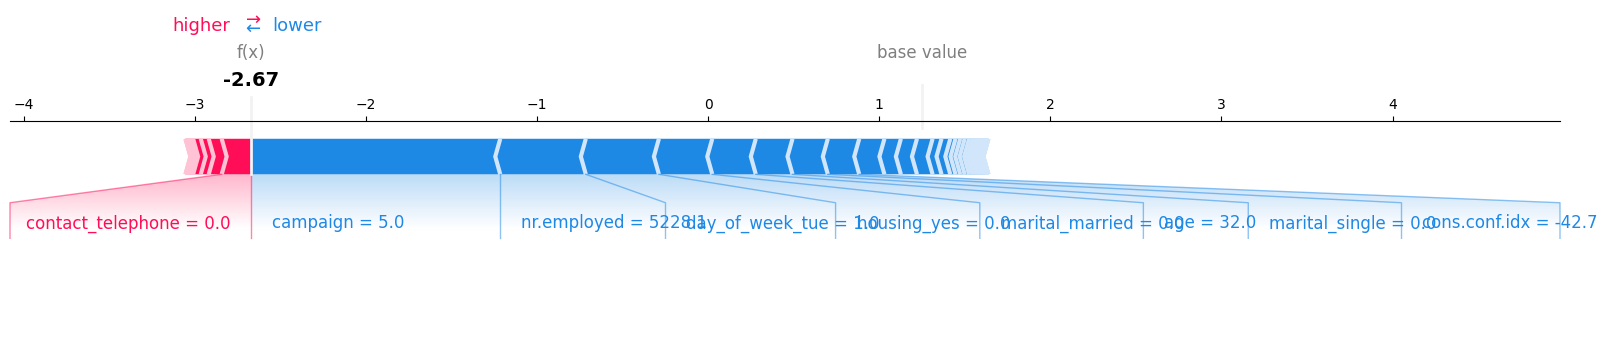

In [ ]:
from lightgbm import LGBMClassifier
import shap
import matplotlib.pyplot as plt

print("\n--- SHAP EXPLANATION FOR LIGHTGBM ---")
explainer_lgbm = shap.TreeExplainer(final_lgbm_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_test_s)

if isinstance(shap_values_lgbm, list):
    expected_value_lgbm = explainer_lgbm.expected_value[1] if isinstance(explainer_lgbm.expected_value, (list, np.ndarray)) else explainer_lgbm.expected_value
    shap_values_lgbm = shap_values_lgbm[1]
else:
    expected_value_lgbm = explainer_lgbm.expected_value

# 1. Global Bar Plot
plt.figure()
plt.title("LGBM - Feature Importance (Bar Plot)")
shap.summary_plot(shap_values_lgbm, X_test_s, feature_names=X.columns, plot_type="bar")

# 2. Summary Plot
plt.figure()
shap.summary_plot(shap_values_lgbm, X_test_s, feature_names=X.columns)

# 3. Dependence Plot
plt.figure()
shap.dependence_plot(X.columns[0], shap_values_lgbm, X_test_s, feature_names=X.columns)

# 4. Force Plot
shap.initjs()
shap.force_plot(expected_value_lgbm, shap_values_lgbm[0,:], X_test.iloc[0,:], feature_names=X.columns, matplotlib=True)

In [19]:
#  LIME EXPLAINABILITY
from lime.lime_tabular import LimeTabularExplainer

print("\n--- LIME EXPLANATION ---")

lime_explainer = LimeTabularExplainer(
    training_data=X_train_s,
    feature_names=X.columns,
    class_names=['Yes', 'No'],
    mode='classification'
)

lime_exp = lime_explainer.explain_instance(
    X_test_s[0],
    final_lgbm_model.predict_proba
)

lime_exp.show_in_notebook(show_table=True)


--- LIME EXPLANATION ---
